In [11]:
#!pip install stop-words

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re, string
import nltk 
from nltk import ngrams
from nltk.corpus import stopwords 
from nltk.tokenize import word_tokenize
from nltk.tokenize import sent_tokenize
from nltk import FreqDist
from nltk.stem import WordNetLemmatizer,SnowballStemmer
nltk.download('punkt')
nltk.download('stopwords')
#from stop_words import get_stop_words
import json
import os

[nltk_data] Downloading package punkt to /home/alicemusso/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/alicemusso/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [5]:
base_dir = "."
ids_file = os.path.join(base_dir, "os-ccby-40k-ids.csv")
json_dir = os.path.join(base_dir, "json")
output_csv = os.path.join(base_dir, "articles.csv")

# Read the IDs from the CSV file (assuming no header row in the CSV)
print(f"Reading IDs from {ids_file}...")
ids_df = pd.read_csv(ids_file, header=None, names=["doc_id"])
ids_list = ids_df["doc_id"].tolist()

articles = []

print(f"Processing {len(ids_list)} articles...")
for doc_id in ids_list:
    json_path = os.path.join(json_dir, f"{doc_id}.json")
    
    if os.path.exists(json_path):
        with open(json_path, 'r', encoding='utf-8') as f:
            try:
                article_data = json.load(f)
                
                record = {"doc_id": doc_id}
                for key, value in article_data.items():
                    if key == "metadata" and isinstance(value, dict):
                        # Flatten metadata into separate columns
                        for meta_k, meta_v in value.items():
                            if isinstance(meta_v, list):
                                # Handle lists of dicts (like authors) or simple lists (like keywords)
                                if len(meta_v) > 0 and isinstance(meta_v[0], dict) and "last" in meta_v[0]:
                                    record[meta_k] = ", ".join([f"{a.get('first', '')} {a.get('last', '')}".strip() for a in meta_v])
                                else:
                                    record[meta_k] = ", ".join([str(i) for i in meta_v])
                            else:
                                record[meta_k] = meta_v
                    elif key in ["author_highlights", "body_text"] and isinstance(value, list):
                        # Extract only the raw text from the "sentence" attributes
                        record[key] = " ".join([item.get("sentence", "") for item in value if isinstance(item, dict) and "sentence" in item])
                    elif key == "bib_entries" and isinstance(value, dict):
                        # Extract titles and years from bibliographies
                        bibs = [v.get("title", "") + (f" ({v.get('pub_year')})" if v.get("pub_year") else "") for k, v in value.items() if isinstance(v, dict) and v.get("title")]
                        record[key] = " | ".join(bibs)
                    elif isinstance(value, (dict, list)):
                        # Fallback for any other unhandled complex types
                        record[key] = json.dumps(value, ensure_ascii=False)
                    else:
                        record[key] = value
                        
                articles.append(record)
            except json.JSONDecodeError:
                print(f"Warning: Could not decode JSON for file {json_path}")

# Create a DataFrame and save it to CSV
output_df = pd.DataFrame(articles)
output_df.to_csv(output_csv, index=False, encoding='utf-8')
print(f"Success! Dataset created at {output_csv} with {len(output_df)} records.")


Reading IDs from ./os-ccby-40k-ids.csv...
Processing 40001 articles...
Success! Dataset created at ./articles.csv with 40001 records.


In [6]:
#import and visualize dataset
df = pd.read_csv("articles.csv", skipinitialspace=True)
df

,doc_id,abstract,bib_entries,body_text,docId,asjc,authors,doi,firstpage,issn,lastpage,openaccess,pub_year,subjareas,title,keywords,author_highlights
0,S2352340916308101,The data presented here were originally collec...,The Analysis of Spatial Association by Use of ...,"However, a key limitation of this approach usi...",S2352340916308101,1000,"Juan Miguel Rodriguez Lopez, Katharina Heider,...",10.1016/j.dib.2016.12.049,5,23523409,11,Full,2017,MULT,Human and remote sensing data to investigate t...,NaN,NaN
1,S2352340916300440,An easy method that combined gel casting and p...,Fabrication of porous poly (lactic acid-co-gly...,The compressive stress–strain curves of carbon...,S2352340916300440,1000,"Yao Yao, Fei Chen, Xi Chen, Qiang Shen, Lianme...",10.1016/j.dib.2016.02.022,117,23523409,122,Full,2016,MULT,Data of microstructure and mechanical properti...,"Carbon foams, Material design, Mechanical prop...",NaN
2,S2352340919302719,The survey data presented in this article prov...,Tracking the invasion of the alien fruit pest ...,The surveys questions varied with a minimum of...,S2352340919302719,1000,"Ladina Knapp, Esther Bravin, Robert Finger",10.1016/j.dib.2019.103920,NaN,23523409,NaN,Full,2019,MULT,Data on Swiss fruit and wine growers’ manageme...,"Berries, Cherries, D. suzukii, Grapes, Locus o...",NaN
3,S2352340918301756,This article includes data from the research a...,The most painful site of maxillary anterior in...,Exclusion criteria: hypersensitivity to the in...,S2352340918301756,1000,"Roohollah Sharifi, Hamid Reza Mozaffari, Hesam...",10.1016/j.dib.2018.02.055,1352,23523409,1354,Full,2018,MULT,Data on the pain of infiltration area in injec...,NaN,NaN
4,S2352340918301355,The present study investigated the effect of h...,"Global, regional, and national causes of under...",Diarrheal diseases are one of the major causes...,S2352340918301355,1000,"Mina Riahi, Ali Akbar Mohammadi, Vahid Kazemi ...",10.1016/j.dib.2018.02.019,954,23523409,960,Full,2018,MULT,Diarrhea deaths in children among countries wi...,"Diarrhea, Drinking water, Human development in...",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39996,S2352551716300415,Background For TDM of mycophenolate acid (MPA)...,The role of mycophenolate mofetil in kidney tr...,The Bland-Altman plot analysis demonstrated th...,S2352551716300415,"1308, 3614","François Parant, Bruno Ranchin, Marie Claude G...",10.1016/j.plabm.2016.12.002,19,23525517,26,Full,2017,"BIOC, HEAL",The Roche Total Mycophenolic Acid® assay: An a...,"Enzyme assay, Inosine monophosphate dehydrogen...",Adaptation of the Roche Total Mycophenolic Aci...
39997,S2352551716300063,Objectives: Anti-pneumococcal capsular polysac...,Practice parameter for the diagnosis and manag...,We hypothesise that the simultaneous measureme...,S2352551716300063,"1308, 3614","Antony R. Parker, Syreeta Allen, Stephen Harding",10.1016/j.plabm.2016.02.004,1,23525517,5,Full,2016,"BIOC, HEAL",Concentration of anti-pneumococcal capsular po...,"Anti-pneumococcal capsular polysaccharide IgA,...",NaN
39998,S2352551717300574,Background Blood gas analyzers are often integ...,Fetal scalp blood sampling for pH and lactate ...,"Furthermore, it has been demonstrated that qua...",S2352551717300574,"1308, 3614","Charlotte Oris, Yoan Clavel, Matthieu Jabaudon...",10.1016/j.plabm.2017.12.001,21,23525517,33,Full,2018,"BIOC, HEAL",Method validation of a set of 12 GEM® Premier™...,"Blood gas, Method validation, NF ISO 15189, NF...",Complete method validation of 12 analyzers for...
39999,S2352551719300423,Objectives: We report the analytical performan...,Overview of procalcitonin assays and procalcit...,"However, these three measurements remain close...",S2352551719300423,"1308, 3614","Anne Marie Dupuy, Anne Sophie Bargnoux, Aneta ...",10.1016/j.plabm.2019.e00145,NaN,23525517,NaN,Full,2020,"BIOC, HEAL",Analytical performances of a novel point-of-ca...,"Clinical concordance, Correlation, PCT, Precision",NaN


In [7]:
(df["doc_id"] == df["docId"]).all()

np.True_

In [8]:
df.drop(columns=["docId"], inplace=True)

In [9]:
df.head()

,doc_id,abstract,bib_entries,body_text,asjc,authors,doi,firstpage,issn,lastpage,openaccess,pub_year,subjareas,title,keywords,author_highlights
0,S2352340916308101,The data presented here were originally collec...,The Analysis of Spatial Association by Use of ...,"However, a key limitation of this approach usi...",1000,"Juan Miguel Rodriguez Lopez, Katharina Heider,...",10.1016/j.dib.2016.12.049,5,23523409,11,Full,2017,MULT,Human and remote sensing data to investigate t...,NaN,NaN
1,S2352340916300440,An easy method that combined gel casting and p...,Fabrication of porous poly (lactic acid-co-gly...,The compressive stress–strain curves of carbon...,1000,"Yao Yao, Fei Chen, Xi Chen, Qiang Shen, Lianme...",10.1016/j.dib.2016.02.022,117,23523409,122,Full,2016,MULT,Data of microstructure and mechanical properti...,"Carbon foams, Material design, Mechanical prop...",NaN
2,S2352340919302719,The survey data presented in this article prov...,Tracking the invasion of the alien fruit pest ...,The surveys questions varied with a minimum of...,1000,"Ladina Knapp, Esther Bravin, Robert Finger",10.1016/j.dib.2019.103920,NaN,23523409,NaN,Full,2019,MULT,Data on Swiss fruit and wine growers’ manageme...,"Berries, Cherries, D. suzukii, Grapes, Locus o...",NaN
3,S2352340918301756,This article includes data from the research a...,The most painful site of maxillary anterior in...,Exclusion criteria: hypersensitivity to the in...,1000,"Roohollah Sharifi, Hamid Reza Mozaffari, Hesam...",10.1016/j.dib.2018.02.055,1352,23523409,1354,Full,2018,MULT,Data on the pain of infiltration area in injec...,NaN,NaN
4,S2352340918301355,The present study investigated the effect of h...,"Global, regional, and national causes of under...",Diarrheal diseases are one of the major causes...,1000,"Mina Riahi, Ali Akbar Mohammadi, Vahid Kazemi ...",10.1016/j.dib.2018.02.019,954,23523409,960,Full,2018,MULT,Diarrhea deaths in children among countries wi...,"Diarrhea, Drinking water, Human development in...",NaN


In [10]:
pd.set_option('display.max_colwidth', None)

In [11]:
df.head(1)

doc_id  \
0  S2352340916308101   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            abstract  \
0  The data presented here were originally collected for the article “Frontiers of Urbanization: Identifying and Explaining Urbanization Hot Spots in the South of Mexico City Using Human and Remote Sensing” (Rodriguez et al. 2017) [4]. They were divided into three databases (remote sensing, human sensing, and census information), using a multi-method approach with the goal of analyzing the impact of urbanization on protected areas in southern Mexico City. The remote sensing database was prepared as a result of a semi-automatic classification, dividing the land cover data into urban and non-urban classes. The second data set details an alternative view of the phenomena of urbanization by concentrating on illegal settlements in the conservation zone. It was based on voluntary complaints about environmental and land use offences filed at the Procuraduria Ambiental y del Ordenamiento Territorial del Distrito Federal (PAOT), which is a governmental entity responsible for reviewing and processing grievances on five basic topics: illegal land use, deterioration of green areas, waste, noise/vibrations, and animals. Anyone can file a PAOT complaint by phone, electronically, or in person. The complaint ends with a resolution, act of conciliation, or recommendation for action by other actors, such as the police or health office. The third data about unemployment was extracted from Mexico׳s National Census 2010 database available via public access.   

                                                                                                                                                                                                                                                                                                             bib_entries  \
0  The Analysis of Spatial Association by Use of Distance Statistics (1992) | Local Spatial Autocorrelation Statistics: Distributional Issues and an Application (1995) | Frontiers of urbanization: Identifying and explaining urbanization hot spots in the south of Mexico City using human and remote sensing (2017)   

                                                                                                                                                                                                                                                                                                                                                                                                                   

In [13]:
pd.reset_option('display.max_colwidth')

In [14]:
df["openaccess"].unique()
df["openaccess"].value_counts()

openaccess
Full          39954
Repository       34
Name: count, dtype: int64

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40001 entries, 0 to 40000
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   doc_id             40001 non-null  str  
 1   abstract           39525 non-null  str  
 2   bib_entries        38830 non-null  str  
 3   body_text          40001 non-null  str  
 4   asjc               40001 non-null  str  
 5   authors            39994 non-null  str  
 6   doi                39999 non-null  str  
 7   firstpage          35366 non-null  str  
 8   issn               40001 non-null  str  
 9   lastpage           35274 non-null  str  
 10  openaccess         39988 non-null  str  
 11  pub_year           40001 non-null  int64
 12  subjareas          40001 non-null  str  
 13  title              40001 non-null  str  
 14  keywords           35505 non-null  str  
 15  author_highlights  24850 non-null  str  
dtypes: int64(1), str(15)
memory usage: 4.9 MB


In [16]:
df[df["openaccess"] == "Repository"]

,doc_id,abstract,bib_entries,body_text,asjc,authors,doi,firstpage,issn,lastpage,openaccess,pub_year,subjareas,title,keywords,author_highlights
4791,S0014579314006176,Sister chromatid cohesion involves entrapment ...,iMOSFLM: A new graphical interface for diffrac...,A more sensitive assay is to measure the abili...,"1303, 1304, 1307, 1311, 1312, 1315","Maurici B. Roig, Jan Löwe, Kok Lung Chan, Fréd...",10.1016/j.febslet.2014.08.015,3692,00145793,3702,Repository,2014,BIOC,Structure and function of cohesin's Scc3/SA re...,"Cohesin complex, Eco1 acetylation, Maintenance...","Crystal structure of cohesin subunit Scc3/SA, ..."
4823,S0014579314008199,Golgi Arf1-guanine nucleotide exchange factors...,The small G proteins of the Arf family and the...,Fungal life is crucially dependent on exocytos...,"1303, 1304, 1307, 1311, 1312, 1315","Herbert N. Arst, Miguel Hernandez-Gonzalez, Mi...",10.1016/j.febslet.2014.11.014,4799,00145793,4806,Repository,2014,BIOC,GBF/Gea mutant with a single substitution sust...,"BIG/Sec7-subfamily, Fungal secretion, GBF/Gea-...",A. nidulans has a GBF/Gea and a BIG/Sec7 subfa...
4898,S001457931400578X,Understanding how single nucleotide polymorphi...,CARD15 mutations in Blau syndrome (2001) | Gen...,Chemical reagents were obtained from Sigma–Ald...,"1303, 1304, 1307, 1311, 1312, 1315","Rhiannon Parkhouse, Joseph P. Boyle, Tom P. Monie",10.1016/j.febslet.2014.07.029,3382,00145793,3389,Repository,2014,BIOC,Blau syndrome polymorphisms in NOD2 identify n...,"Blau syndrome, Innate immunity, NACHT, Nucleot...",NOD2 SNPs that cause Blau syndrome cluster in ...
4950,S0014579314009065,Recent studies have indicated that non-coding ...,Origin and physiological roles of inflammation...,"Cells were subsequently incubated for 6 h, dil...","1303, 1304, 1307, 1311, 1312, 1315","James A. Heward, Benoit T. Roux, Mark A. Lindsay",10.1016/j.febslet.2014.12.026,396,00145793,406,Repository,2015,BIOC,Divergent signalling pathways regulate lipopol...,"ERK and p38, Enhancer RNA, Lipopolysaccharide,...",eRNAs are expressed from enhancers and have be...
5242,S0014579314004256,PEX5 acts as a cycling receptor for import of ...,Getting a camel through the eye of a needle: t...,Peroxisomal matrix proteins are post-translati...,"1303, 1304, 1307, 1311, 1312, 1315","Thomas Lanyon-Hogg, Jacob Hooper, Sarah Gunn, ...",10.1016/j.febslet.2014.05.038,2223,00145793,2229,Repository,2014,BIOC,PEX14 binding to Arabidopsis PEX5 has differen...,"Arabidopsis thaliana, Cargo unloading, PEX14, ...",The interaction between Arabidopsis PEX5 and P...
5274,S0014579314000283,We describe a simple method for the determinat...,Control of metalloprotein redox potentials: Wh...,The protein was then passed through a Ni-NTA c...,"1303, 1304, 1307, 1311, 1312, 1315","Igor Efimov, Gary Parkin, Elizabeth S. Millett...",10.1016/j.febslet.2013.12.030,701,00145793,704,Repository,2014,BIOC,A simple method for the determination of reduc...,"Heme, Heme protein, Redox, Reduction potential",A simple method for determination of heme prot...
6077,S0014579313009204,The Atg2-Atg18 complex acts in parallel to Atg...,Autophagy fights disease through cellular self...,In line with the interaction of Atg18 with thi...,"1303, 1304, 1307, 1311, 1312, 1315","Péter Nagy, Krisztina Hegedus, Karolina Pircs,...",10.1016/j.febslet.2013.12.012,408,00145793,413,Repository,2014,BIOC,Different effects of Atg2 and Atg18 mutations ...,"Atg18, Atg2, Atg7, Atg8a, Atg9, Ref(2)P/p62",Atg9 and Atg18 are required for autophagy upst...
6079,S0014579315000897,Abstract Aurone synthase from Coreopsis grandi...,"μ-η2:η2-Peroxo Binuclear Copper Complex, [Cu(H...",GST-tag was bound onto the column and the unta...,"1303, 1304, 1307, 1311, 1312, 1315","Cornelia Kaintz, Rupert L. Mayer, Franz Jirsa,...",10.1016/j.febslet.2015.02.009,789,00145793,797,Repository,2015,BIOC,Site-directed mutagenesis around the CuA site ...,"4-Deoxyaurone, Aurone synthase (AUS), Copper b...",Site-directed mutations of AUS1 around the CuA.

In [17]:
df.drop(columns=["doi", "firstpage", "issn", "lastpage"], inplace=True)

In [18]:
df.drop(columns=["author_highlights"], inplace=True)

In [19]:
df.drop(columns=["keywords"], inplace=True)

In [20]:
df.drop(columns=["bib_entries"], inplace=True)

In [21]:
df.dropna(inplace=True)

In [22]:
df.isnull().sum()

doc_id        0
abstract      0
body_text     0
asjc          0
authors       0
openaccess    0
pub_year      0
subjareas     0
title         0
dtype: int64

In [23]:
df.head()

,doc_id,abstract,body_text,asjc,authors,openaccess,pub_year,subjareas,title
0,S2352340916308101,The data presented here were originally collec...,"However, a key limitation of this approach usi...",1000,"Juan Miguel Rodriguez Lopez, Katharina Heider,...",Full,2017,MULT,Human and remote sensing data to investigate t...
1,S2352340916300440,An easy method that combined gel casting and p...,The compressive stress–strain curves of carbon...,1000,"Yao Yao, Fei Chen, Xi Chen, Qiang Shen, Lianme...",Full,2016,MULT,Data of microstructure and mechanical properti...
2,S2352340919302719,The survey data presented in this article prov...,The surveys questions varied with a minimum of...,1000,"Ladina Knapp, Esther Bravin, Robert Finger",Full,2019,MULT,Data on Swiss fruit and wine growers’ manageme...
3,S2352340918301756,This article includes data from the research a...,Exclusion criteria: hypersensitivity to the in...,1000,"Roohollah Sharifi, Hamid Reza Mozaffari, Hesam...",Full,2018,MULT,Data on the pain of infiltration area in injec...
4,S2352340918301355,The present study investigated the effect of h...,Diarrheal diseases are one of the major causes...,1000,"Mina Riahi, Ali Akbar Mohammadi, Vahid Kazemi ...",Full,2018,MULT,Diarrhea deaths in children among countries wi...


In [24]:
# keep=False ti mostra sia l'originale che tutte le copie presenti
duplicati_completi = df[df.duplicated(subset=['body_text'], keep=False)]
 
# Ordina i risultati per vedere i blocchi uguali uno sotto l'altro
duplicati_completi = duplicati_completi.sort_values(by=['body_text'])
print(duplicati_completi)



                  doc_id                                           abstract  \
1046   S1090023317301910  The recent outbreak of infection with Zika vir...   
1242   S1090023314005309  Beagles are commonly used in vaccine trials as...   
10048  S2590155919300010  Sorbitol can be produced photosynthetically in...   
16416  S0025326X19308781  Marine debris, particularly plastic and abando...   

                                               body_text              asjc  \
1046   None of the authors of this paper has a financ...        1103, 3400   
1242   None of the authors of this paper has a financ...        1103, 3400   
10048  The authors declare that they have no known co...  1305, 1502, 2402   
16416  The authors declare that they have no known co...  1104, 1910, 2310   

                                                 authors openaccess  pub_year  \
1046   Jamie Royle, Claire L. Donald, Andres Merits, ...       Full      2017   
1242   Francesca Soutter, Lorna J. Kennedy, William

In [25]:
# Calculate word counts for the text column (e.g., 'body_text')
word_counts = df['body_text'].str.split().str.len()

# Create a boolean mask of rows that exceed 40,000 words
over_limit_mask = word_counts > 40000

# Reassign the DataFrame to keep only the rows that are NOT (~) over the limit
df = df[~over_limit_mask]

# Optional: Print the number of dropped rows to verify
dropped_count = over_limit_mask.sum()
print(f"Dropped {dropped_count} rows containing over 40,000 words.")

Dropped 3 rows containing over 40,000 words.


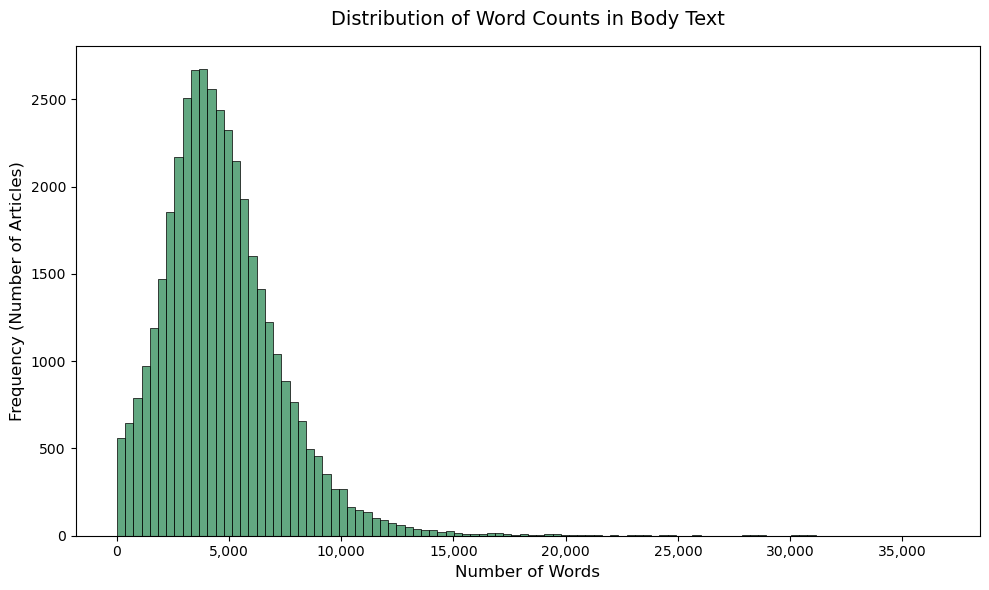

In [26]:
word_counts = df['body_text'].dropna().str.split().str.len()

plt.figure(figsize=(10, 6))

sns.histplot(x=word_counts, bins=100, color='seagreen')

plt.title('Distribution of Word Counts in Body Text', fontsize=14, pad=15)
plt.xlabel('Number of Words', fontsize=12)
plt.ylabel('Frequency (Number of Articles)', fontsize=12)

plt.gca().xaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()


In [27]:
df['word_count'] = df['body_text'].fillna('').str.split().str.len()

df_sorted = df.sort_values(by='word_count', ascending=True)


In [28]:

df_sorted[['doc_id', 'word_count', 'body_text']].head(100)

,doc_id,word_count,body_text
30800,S2352771416300192,4,Conflicts of interest: none.
29610,S221454001500002X,6,The authors declare no completing interests.
27810,S1672022918304327,6,The authors declare no competing interests.
20350,S2590150819300389,6,There are no conflicts of interest.
25357,S2213224418300373,7,The authors have no conflicts of interest.
...,...,...,...
27414,S0022247X19308339,54,A. Atzmon in [1] published a construction of a...
38083,S0370269317309036,55,We hope that the techniques developed here wil...
27589,S1063520318301623,56,"We, however, do not pursue this issue here and..."
4684,S0047637416300069,56,"CF, SW and BP performed mouse work. We certify..."


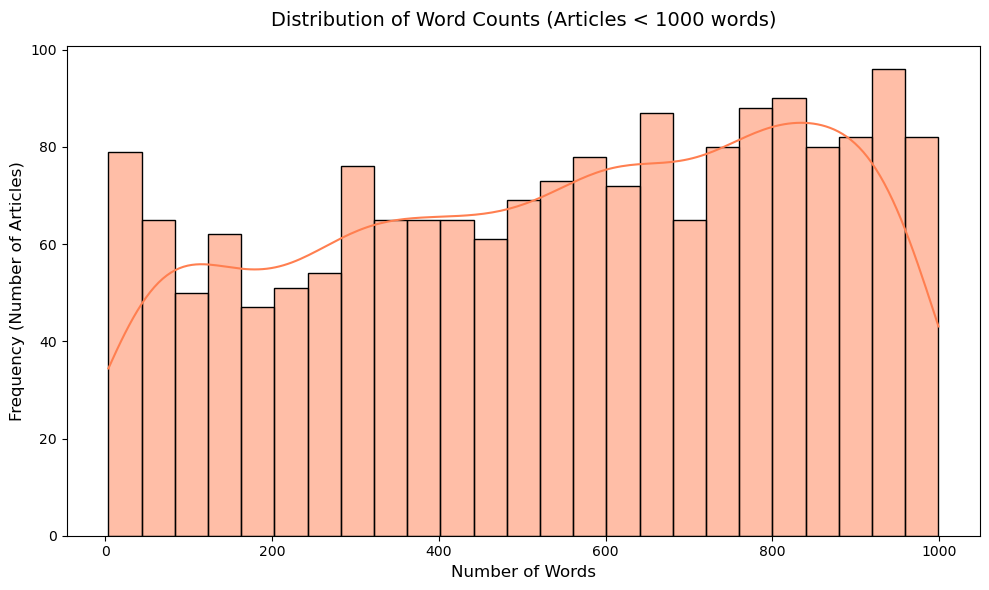

In [29]:
word_counts = df['body_text'].fillna('').str.split().str.len()

short_articles = word_counts[word_counts < 1000]

plt.figure(figsize=(10, 6))

sns.histplot(short_articles, bins=25, kde=True, color='coral')

plt.title('Distribution of Word Counts (Articles < 1000 words)', fontsize=14, pad=15)
plt.xlabel('Number of Words', fontsize=12)
plt.ylabel('Frequency (Number of Articles)', fontsize=12)

plt.tight_layout()
plt.show()


In [30]:
MIN_WORDS_THRESHOLD = 500

word_counts = df['body_text'].fillna('').str.split().str.len()

df = df[word_counts >= MIN_WORDS_THRESHOLD]

dropped_count = len(df) - len(df)
print(f"Dropped {dropped_count} rows with fewer than {MIN_WORDS_THRESHOLD} words.")
print(f"Remaining dataset size: {len(df)} rows.")


Dropped 0 rows with fewer than 500 words.
Remaining dataset size: 38731 rows.


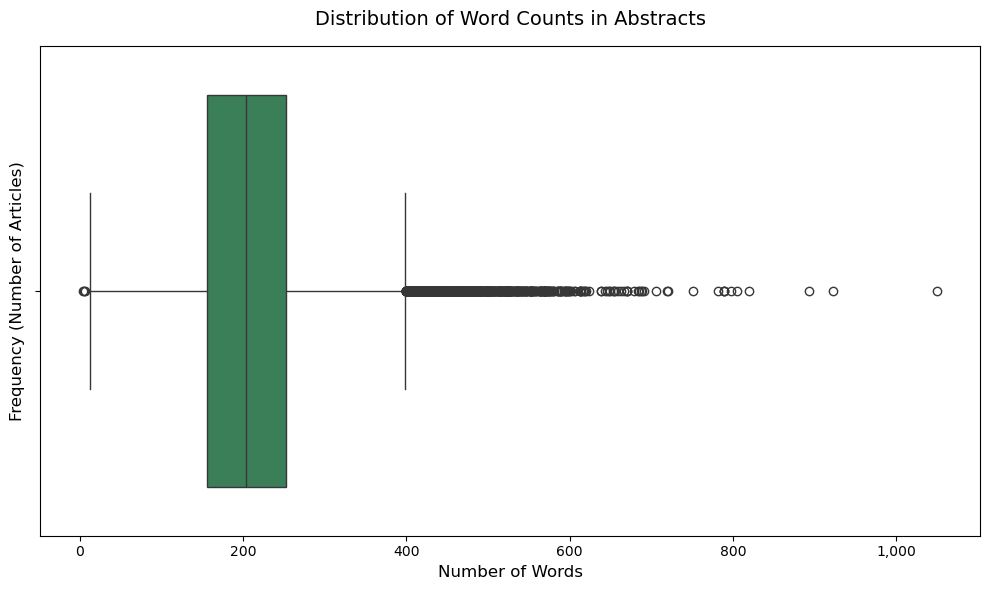

In [38]:
word_counts_abstract = df['abstract'].dropna().str.split().str.len()

plt.figure(figsize=(10, 6))

sns.boxplot(x=word_counts_abstract, color='seagreen')

plt.title('Distribution of Word Counts in Abstracts', fontsize=14, pad=15)
plt.xlabel('Number of Words', fontsize=12)
plt.ylabel('Frequency (Number of Articles)', fontsize=12)

plt.gca().xaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

In [47]:
df['word_count_abstract'] = df['abstract'].fillna('').str.split().str.len()

df_sorted = df.sort_values(by='word_count_abstract', ascending=True)
df_sorted[['doc_id', 'word_count_abstract', 'abstract']].head(20)

,doc_id,word_count_abstract,abstract
30,S2589004219304365,0,NaN
26,S2405844019365715,0,NaN
216,S2589004219301956,0,NaN
272,S2405844019366575,0,NaN
19,S2405844019362917,0,NaN
257,S2589004219304717,0,NaN
69,S240584401936308X,0,NaN
36168,S1359644619304684,17,It is high time to integrate computational mod...
23060,S0269749118353843,17,Crude oil derived monoaromatic hydrocarbons ac...
27623,S2468042716300367,17,We give a brief outline of some of the importa...


In [46]:
df["word_count_abstract"] = df["abstract"].fillna("").str.split().str.len()
df.loc[df["word_count_abstract"] < 15, "abstract"] = np.nan


In [48]:
df.describe()

,pub_year,word_count,word_count_abstract
count,38731.000000,38731.000000,38731.000000
mean,2017.220185,4794.975110,212.794428
std,1.715908,2605.862465,78.419208
min,2014.000000,500.000000,0.000000
25%,2016.000000,3057.500000,156.000000
50%,2017.000000,4410.000000,204.000000
75%,2019.000000,6061.000000,253.000000
max,2020.000000,36630.000000,1050.000000


## ARTICLES TEXT CLEANING

In [49]:
new_stopwords = stopwords.words('english')

In [50]:
#function definition. This function was used to transform words from contracted form to extended form
def fullwords(text):
    text = re.sub(r"can\'t", " can not", text)
    text = re.sub(r"won\'t", " will not", text)
    text = re.sub(r"n\'t", " not", text)
    text = re.sub(r"\'re", " are", text)
    text = re.sub(r"\'s", " is", text)
    text = re.sub(r"\'d", " would", text)
    text = re.sub(r"\'ll", " will", text)
    text = re.sub(r"\'t", " not", text)
    text = re.sub(r"\'ve", " have", text)
    text = re.sub(r"\'m", " am", text)
    text = re.sub(r"wasn\'t", " was not", text)
    text = re.sub(r"i\'ve", " i have", text)
    text = re.sub(r"don\'t", " do not", text)
    text = re.sub(r"didn\'t", " did not", text)
    text = re.sub(r"aint", " am not", text)
    text = re.sub(r"you\'re", " you are", text)
    text = re.sub(r"isn\'t", " is not", text)   
    return text

In [66]:
#Function to  punctuation, links, stopwords, mentions and \r\n new line characters
def strip_all_entities(text): 
    text = re.sub(r'\[.*?\]|\([^)]*\d{4}[^)]*\)', '', text)
    text = re.sub(r'http\S+', '', text) #remove links
    text = re.sub(r'https?://\S+', '', text)
    text = re.sub(r'www\.\S+', '', text)
    text = text.replace('/', ' ') #remove "/"
    text = text.replace('\r', '').replace('\n', ' ').lower() #remove \n and \r and lowercase
    text = re.sub(r'[^\x00-\x7f]',r'', text) #remove non utf8/ascii characters such as '\x9a\x91\x97\x9a\x97'
    banned_list= string.punctuation #remove punctuation

    table = str.maketrans('', '', banned_list)
    text = text.translate(table)
    
    text = [word for word in text.split() if word not in new_stopwords]
    text = ' '.join(text)
    return text

In [67]:
#funzione apply prende una funzione come input e applica questa funzione a un intero DataFrame.
#Se si lavora con dati tabulari, bisogna specificare un asse su cui vuoi che la tua funzione agisca (0 per le colonne e 1 per le righe).

#in a new temporary column "body_clean1" we save the result of the fuction "apply" on the body_text column in our dataset
#function apply takes a function as input (in this case the function "strip_all_entities") and apply it across the entire column of the dataset
df['body_clean1'] = df['body_text'].apply(lambda x: strip_all_entities(x))
#in a new (definitive) column "body_clean" we save the result of the fuction "apply" (with "fullwords" function as input) 
#"body_clean" is the new column of the dataset where the text of each article has been cleaned up
df['body_clean'] = df['body_clean1'].apply(lambda x: fullwords(x))

#eliminate duplicates, if any
df.drop_duplicates("body_clean", inplace=True)

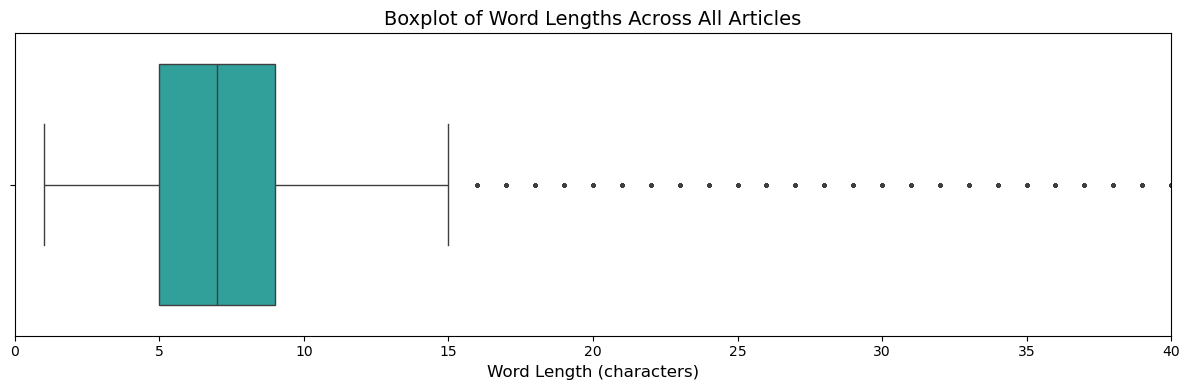

In [70]:
from collections import Counter

word_length_counts = Counter()

for text in df['body_clean'].dropna():
    word_length_counts.update(len(word) for word in text.split())

lengths = list(word_length_counts.keys())
counts = list(word_length_counts.values())
expanded_lengths = np.repeat(lengths, counts)
plt.figure(figsize=(12, 4))
sns.boxplot(x=expanded_lengths, color='lightseagreen', fliersize=2)
plt.title('Boxplot of Word Lengths Across All Articles', fontsize=14)
plt.xlabel('Word Length (characters)', fontsize=12)

plt.xlim(0, 40)

plt.tight_layout()
plt.show()

In [71]:
# Define what constitutes a "long" word
LENGTH_THRESHOLD = 20

# Define how many examples you want to output
NUM_EXAMPLES = 30

long_words = set()

# Iterate through the text column
for text in df['body_clean'].dropna():
    for word in text.split():
        if len(word) > LENGTH_THRESHOLD:
            long_words.add(word)

# Sort the collected words by length in descending (inverse) order
sorted_long_words = sorted(list(long_words), key=len, reverse=True)

print(f"Top {NUM_EXAMPLES} longest unique words in the dataset:")
print("-" * 50)

# Print the sorted words along with their character count for context
for long_word in sorted_long_words[:NUM_EXAMPLES]:
    print(f"{len(long_word)} chars : {long_word}")


Top 30 longest unique words in the dataset:
--------------------------------------------------
134104 chars : ...
628 chars : tor1085002125003443013131app1104002958026297006286app21110023280071054028315des1037001200007112003069des2027001138005133003063des31450031278034353008304unt1074002242008127003085unt2070000250004109002107hor1031001146006140003071hor2042001172006123003078oro1069002330010154004117oro2077002451014190004141srn1012000045002193004076srn2011000044002193004062drf1016000070003306006089drf21640041358035410008322drf3034001126005236005092drf4091002169004409012142mau1040002193005381003125mau2014003063006403003105mau3023002082004438002116mau4017003069006455003116oho1024002091005377003110toi1010003044006197003060toi2016002060005198003058
609 chars : mvskgeednmaiikefmrfkvhmegsvnghefeiegegegrpyegtqtaklkvtkggplpfawdilspqfmygskayvkhpadipdylklsfpegfkwervmnfedggvvtvtqdsslqdgefiykvklrgtnfpsdgpvmqkktmgweassermypedgalkgeikqrlklkdgghydaevkttykakkpvqlpgaynvniklditshnedytiveqyeraegrhstggmde

In [72]:
#eliminate the temporary column "body_clean1"
df= df.drop(["body_clean1"], axis=1)

In [73]:
#to test if the drop function worked well 
df.columns

Index(['doc_id', 'abstract', 'body_text', 'asjc', 'authors', 'openaccess',
       'pub_year', 'subjareas', 'title', 'word_count', 'word_count_abstract',
       'body_clean', 'abstract_clean'],
      dtype='str')

In [74]:
n_nan_abstract = df["abstract"].isna().sum()

df = df.dropna(subset=["abstract"]).copy()

print(f"Abstract eliminati perché NaN: {n_nan_abstract}")

Abstract eliminati perché NaN: 0


In [75]:

df['abstract_clean1'] = df['abstract'].apply(lambda x: strip_all_entities(x))
df['abstract_clean'] = df['abstract_clean1'].apply(lambda x: fullwords(x))
df= df.drop(["abstract_clean1"], axis=1)

df.drop_duplicates("abstract_clean", inplace=True)

In [76]:
df.head(100)

,doc_id,abstract,body_text,asjc,authors,openaccess,pub_year,subjareas,title,word_count,word_count_abstract,body_clean,abstract_clean
0,S2352340916308101,The data presented here were originally collec...,"However, a key limitation of this approach usi...",1000,"Juan Miguel Rodriguez Lopez, Katharina Heider,...",Full,2017,MULT,Human and remote sensing data to investigate t...,976,216,however key limitation approach using arcgis c...,data presented originally collected article fr...
1,S2352340916300440,An easy method that combined gel casting and p...,The compressive stress–strain curves of carbon...,1000,"Yao Yao, Fei Chen, Xi Chen, Qiang Shen, Lianme...",Full,2016,MULT,Data of microstructure and mechanical properti...,844,84,compressive stressstrain curves carbon foams p...,easy method combined gel casting physical foam...
2,S2352340919302719,The survey data presented in this article prov...,The surveys questions varied with a minimum of...,1000,"Ladina Knapp, Esther Bravin, Robert Finger",Full,2019,MULT,Data on Swiss fruit and wine growers’ manageme...,1745,141,surveys questions varied minimum 37 questions ...,survey data presented article provides informa...
6,S2352340918308400,Initial participants were 79 children who were...,Ability estimates were generated using a Rasch...,1000,"Bethany Rittle-Johnson, Erica L. Zippert, Kath...",Full,2018,MULT,"Data on preschool children׳s math, patterning,...",603,183,ability estimates generated using rasch model ...,initial participants 79 children recruited six...
7,S2352340916303766,"The data presented here comprise clinical, neu...",The goal was to eliminate the d׳s with exactly...,1000,"Catherine M. Sweeney-Reed, Tino Zaehle, Jürgen...",Full,2016,MULT,"Clinical, neuropsychological, and pre-stimulus...",549,185,goal eliminate ds exactly two marks top two bo...,data presented comprise clinical neuropsycholo...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
158,S2352340917303803,The dataset depicted in this article related t...,The Swiss albino mice were divided into 7 grou...,1000,"Muthukirshnan Saradhadevi, Murugesan Gnanadesi...",Full,2017,MULT,Dataset on antitumor properties of silver nano...,739,142,swiss albino mice divided 7 groups six animals...,dataset depicted article related earlier artic...
159,S2352340915001699,Genotoxicity testing is a critical component o...,Agilent Feature Extraction.TXT files were read...,1000,"Andrew Williams, Julie K. Buick, Ivy Moffat, C...",Full,2015,MULT,A predictive toxicogenomics signature to class...,1055,208,agilent feature extractiontxt files read r env...,genotoxicity testing critical component chemic...
160,S2352340918311946,"γ-Glutamyltransferases (GGTs) are widespread, ...",Ethanol was then added (2 mL/mmol of expected ...,1000,"Cinzia Calvio, Fabio Romagnuolo, Francesca Vul...",Full,2018,MULT,Data for the synthesis of oligo-γ-glutamylglut...,911,214,ethanol added 2 ml mmol expected product stirr...,glutamyltransferases ggts widespread conserved...
162,S235234091830605X,This article contains data and summary statist...,This database has been updated three times sin...,1000,"Richard Bryce, Ignacio Losada Carreño, Andrew ...",Full,2018,MULT,Annually and monthly resolved solar irradiance...,750,132,database updated three times since initial pub...,article contains data summary statistics solar...


## TOKENIZATION

In [79]:
#TOKENIZATION
def tokenization(text):
    text = re.split('\W+', text)
    return text

df['body_tokenized'] = df['body_clean'].apply(lambda x: tokenization(x))
df['body_tok=2'] = df['body_tokenized'].apply(lambda words: list(nltk.ngrams(words, 2)))
df.head(10)

,doc_id,abstract,body_text,asjc,authors,openaccess,pub_year,subjareas,title,word_count,word_count_abstract,body_clean,abstract_clean,body_tokenized,body_tok=2
0,S2352340916308101,The data presented here were originally collec...,"However, a key limitation of this approach usi...",1000,"Juan Miguel Rodriguez Lopez, Katharina Heider,...",Full,2017,MULT,Human and remote sensing data to investigate t...,976,216,however key limitation approach using arcgis c...,data presented originally collected article fr...,"[however, key, limitation, approach, using, ar...","[(however, key), (key, limitation), (limitatio..."
1,S2352340916300440,An easy method that combined gel casting and p...,The compressive stress–strain curves of carbon...,1000,"Yao Yao, Fei Chen, Xi Chen, Qiang Shen, Lianme...",Full,2016,MULT,Data of microstructure and mechanical properti...,844,84,compressive stressstrain curves carbon foams p...,easy method combined gel casting physical foam...,"[compressive, stressstrain, curves, carbon, fo...","[(compressive, stressstrain), (stressstrain, c..."
2,S2352340919302719,The survey data presented in this article prov...,The surveys questions varied with a minimum of...,1000,"Ladina Knapp, Esther Bravin, Robert Finger",Full,2019,MULT,Data on Swiss fruit and wine growers’ manageme...,1745,141,surveys questions varied minimum 37 questions ...,survey data presented article provides informa...,"[surveys, questions, varied, minimum, 37, ques...","[(surveys, questions), (questions, varied), (v..."
6,S2352340918308400,Initial participants were 79 children who were...,Ability estimates were generated using a Rasch...,1000,"Bethany Rittle-Johnson, Erica L. Zippert, Kath...",Full,2018,MULT,"Data on preschool children׳s math, patterning,...",603,183,ability estimates generated using rasch model ...,initial participants 79 children recruited six...,"[ability, estimates, generated, using, rasch, ...","[(ability, estimates), (estimates, generated),..."
7,S2352340916303766,"The data presented here comprise clinical, neu...",The goal was to eliminate the d׳s with exactly...,1000,"Catherine M. Sweeney-Reed, Tino Zaehle, Jürgen...",Full,2016,MULT,"Clinical, neuropsychological, and pre-stimulus...",549,185,goal eliminate ds exactly two marks top two bo...,data presented comprise clinical neuropsycholo...,"[goal, eliminate, ds, exactly, two, marks, top...","[(goal, eliminate), (eliminate, ds), (ds, exac..."
8,S2405844018309484,Background: Pseudoexfoliation syndrome (PES) i...,"As can be seen, to what extent ocular PES is a...",1000,"Jon Klokk Slettedal, Leiv Sandvik, Amund Ringvold",Full,2018,MULT,Lifespan reduction due to neoplasia is nullifi...,2706,261,seen extent ocular pes associated functional a...,background pseudoexfoliation syndrome pes comm...,"[seen, extent, ocular, pes, associated, functi...","[(seen, extent), (extent, ocular), (ocular, pe..."
9,S2405844017327330,In the framework of understanding the transpor...,The limit of detection of the method is 0.013 ...,1000,"M. Breida, S. Alami Younssi, A. Bouazizi, B. A...",Full,2018,MULT,Nitrate removal from aqueous solutions by γ-Al...,4248,241,limit detection method 0013 mg l based results...,framework understanding transport mechanism go...,"[limit, detection, method, 0013, mg, l, based,...","[(limit, detection), (detection, method), (met..."
10,S2352340916300506,Aberrant histone post-translational modificati...,This proteomics dataset comprise LC-MS/MS raw ...,1000,"Roberta Noberini, Giancarlo Pruneri, Saverio M...",Full,2016,MULT,Mass-spectrometry analysis of histone post-tra...,1614,155,proteomics dataset comprise lcms ms raw files ...,aberrant histone posttranslational modificatio...,"[proteomics, dataset, comprise, lcms, ms, raw,...","[(proteomics, dataset), (dataset, comprise), (..."
12,S2352340918301781,This data article contains descriptive and exp...,In order to analyze neurogenic differentiation...,1000,"Sujeong Jang, Han Seong Jeong",Full,2018,MULT,Data for the effect of histon

In [83]:
df['abstract_tokenized'] = df['abstract_clean'].apply(lambda x: tokenization(x))
df['abstract_tok=2'] = df['abstract_tokenized'].apply(lambda words: list(nltk.ngrams(words, 2)))
df.head(10)

,doc_id,abstract,body_text,asjc,authors,openaccess,pub_year,subjareas,title,word_count,word_count_abstract,body_clean,abstract_clean,body_tokenized,body_tok=2,body_lemmatized,abstract_tokenized,abstract_tok=2
0,S2352340916308101,The data presented here were originally collec...,"However, a key limitation of this approach usi...",1000,"Juan Miguel Rodriguez Lopez, Katharina Heider,...",Full,2017,MULT,Human and remote sensing data to investigate t...,976,216,however key limitation approach using arcgis c...,data presented originally collected article fr...,"[however, key, limitation, approach, using, ar...","[(however, key), (key, limitation), (limitatio...","[however, key, limitation, approach, use, arcg...","[data, presented, originally, collected, artic...","[(data, presented), (presented, originally), (..."
1,S2352340916300440,An easy method that combined gel casting and p...,The compressive stress–strain curves of carbon...,1000,"Yao Yao, Fei Chen, Xi Chen, Qiang Shen, Lianme...",Full,2016,MULT,Data of microstructure and mechanical properti...,844,84,compressive stressstrain curves carbon foams p...,easy method combined gel casting physical foam...,"[compressive, stressstrain, curves, carbon, fo...","[(compressive, stressstrain), (stressstrain, c...","[compressive, stressstrain, curve, carbon, foa...","[easy, method, combined, gel, casting, physica...","[(easy, method), (method, combined), (combined..."
2,S2352340919302719,The survey data presented in this article prov...,The surveys questions varied with a minimum of...,1000,"Ladina Knapp, Esther Bravin, Robert Finger",Full,2019,MULT,Data on Swiss fruit and wine growers’ manageme...,1745,141,surveys questions varied minimum 37 questions ...,survey data presented article provides informa...,"[surveys, questions, varied, minimum, 37, ques...","[(surveys, questions), (questions, varied), (v...","[survey, question, vary, minimum, 37, question...","[survey, data, presented, article, provides, i...","[(survey, data), (data, presented), (presented..."
6,S2352340918308400,Initial participants were 79 children who were...,Ability estimates were generated using a Rasch...,1000,"Bethany Rittle-Johnson, Erica L. Zippert, Kath...",Full,2018,MULT,"Data on preschool children׳s math, patterning,...",603,183,ability estimates generated using rasch model ...,initial participants 79 children recruited six...,"[ability, estimates, generated, using, rasch, ...","[(ability, estimates), (estimates, generated),...","[ability, estimate, generate, use, rasch, mode...","[initial, participants, 79, children, recruite...","[(initial, participants), (participants, 79), ..."
7,S2352340916303766,"The data presented here comprise clinical, neu...",The goal was to eliminate the d׳s with exactly...,1000,"Catherine M. Sweeney-Reed, Tino Zaehle, Jürgen...",Full,2016,MULT,"Clinical, neuropsychological, and pre-stimulus...",549,185,goal eliminate ds exactly two marks top two bo...,data presented comprise clinical neuropsycholo...,"[goal, eliminate, ds, exactly, two, marks, top...","[(goal, eliminate), (eliminate, ds), (ds, exac...","[goal, eliminate, d, exactly, two, mark, top, ...","[data, presented, comprise, clinical, neuropsy...","[(data, presented), (presented, comprise), (co..."
8,S2405844018309484,Background: Pseudoexfoliation syndrome (PES) i...,"As can be seen, to what extent ocular PES is a...",1000,"Jon Klokk Slettedal, Leiv Sandvik, Amund Ringvold",Full,2018,MULT,Lifespan reduction due to neoplasia is nullifi...,2706,261,seen extent ocular pes associated functional a...,background pseudoexfoliation syndrome pes comm...,"[seen, extent, ocular, pes, associated, functi...","[(seen, extent), (extent, ocular), (ocular, pe...","[see, extent, ocular, pe, associate, functiona...","[background, pseudoexfoliation, syndrome, pes,...","[(background, pseudoexfoliation), (pseudoexfol..."
9,S2405844017327330,In the framework of understanding the transpor...,The limit of detection of the method is 0.013 ...,1000,"M

## LEMMATIZATION

In [ ]:
import nltk
nltk.download('wordnet')

#LEMMATIZATION
wordlemm = WordNetLemmatizer()

def lemmatization(data, wordlemm):    
    new_words_lemm=[]    
    for row in data:        
        new_words_lemm_tmp=[]        
        for word in row:            
            lemm_word = wordlemm.lemmatize(word)            
            lemm_word = wordlemm.lemmatize(lemm_word, pos='v')            
            new_words_lemm_tmp.append(lemm_word)        
        new_words_lemm.append(new_words_lemm_tmp)
    return new_words_lemm

#lemmatization on the dataframe
df["body_lemmatized"] = lemmatization(df["body_tokenized"], wordlemm)  #lemmatizzazione su body_tokenized

[nltk_data] Downloading package wordnet to
[nltk_data]     /home/alicemusso/nltk_data...


In [82]:
df['body_lemmatized']

0        [however, key, limitation, approach, use, arcg...
1        [compressive, stressstrain, curve, carbon, foa...
2        [survey, question, vary, minimum, 37, question...
6        [ability, estimate, generate, use, rasch, mode...
7        [goal, eliminate, d, exactly, two, mark, top, ...
                               ...                        
39996    [blandaltman, plot, analysis, demonstrate, mpa...
39997    [hypothesise, simultaneous, measurement, iga, ...
39998    [furthermore, demonstrate, qualify, nurse, spe...
39999    [however, three, measurement, remain, close, a...
40000    [note, part, inhouse, immunohematology, workup...
Name: body_lemmatized, Length: 38714, dtype: object

In [84]:
df["abstract_lemmatized"] = lemmatization(df["abstract_tokenized"], wordlemm)  #lemmatizzazione su abstract_tokenized

In [85]:
df['abstract_lemmatized']

0        [data, present, originally, collect, article, ...
1        [easy, method, combine, gel, cast, physical, f...
2        [survey, data, present, article, provide, info...
6        [initial, participant, 79, child, recruit, six...
7        [data, present, comprise, clinical, neuropsych...
                               ...                        
39996    [background, tdm, mycophenolate, acid, mpa, ro...
39997    [objective, antipneumococcal, capsular, polysa...
39998    [background, blood, gas, analyzer, often, inte...
39999    [objective, report, analytical, performance, n...
40000    [antia1, antibody, find, usually, clinically, ...
Name: abstract_lemmatized, Length: 38714, dtype: object

In [87]:
#to test if the lemmatization worked well
print(df['body_clean'][34560], df['body_lemmatized'][34560])
print(df['abstract_clean'][34560], df['abstract_lemmatized'][34560])
df.shape

thapar et als scale used capture number seizures type patient experienced previous 12 months participants aged 16 years patients needed report diagnosis epilepsy type least one year analyses performed using spss 220 ibm armonk ny usa basis qualitative evidence concerning impacts epilepsy patient perspective participants asked rate importance 5 additional domains order overlook domains importance patients carers participants invited record aspects outcome important basis roundtable discussions among health professionals ilae come suggested outcome domains epilepsy drug trials measure considerable variability aspects outcome trial investigators measure report systematic effort ask patients carers outcomes important scoring system used cos studies discriminate importance different domains could suggest similar findings might found western countries 3 20 accessed cited epilepsy cochrane reviews 2014 described problems due inconsistencies outcomes reported trials part study patients carers 

(38714, 19)

In [88]:
df.head(5)

,doc_id,abstract,body_text,asjc,authors,openaccess,pub_year,subjareas,title,word_count,word_count_abstract,body_clean,abstract_clean,body_tokenized,body_tok=2,body_lemmatized,abstract_tokenized,abstract_tok=2,abstract_lemmatized
0,S2352340916308101,The data presented here were originally collec...,"However, a key limitation of this approach usi...",1000,"Juan Miguel Rodriguez Lopez, Katharina Heider,...",Full,2017,MULT,Human and remote sensing data to investigate t...,976,216,however key limitation approach using arcgis c...,data presented originally collected article fr...,"[however, key, limitation, approach, using, ar...","[(however, key), (key, limitation), (limitatio...","[however, key, limitation, approach, use, arcg...","[data, presented, originally, collected, artic...","[(data, presented), (presented, originally), (...","[data, present, originally, collect, article, ..."
1,S2352340916300440,An easy method that combined gel casting and p...,The compressive stress–strain curves of carbon...,1000,"Yao Yao, Fei Chen, Xi Chen, Qiang Shen, Lianme...",Full,2016,MULT,Data of microstructure and mechanical properti...,844,84,compressive stressstrain curves carbon foams p...,easy method combined gel casting physical foam...,"[compressive, stressstrain, curves, carbon, fo...","[(compressive, stressstrain), (stressstrain, c...","[compressive, stressstrain, curve, carbon, foa...","[easy, method, combined, gel, casting, physica...","[(easy, method), (method, combined), (combined...","[easy, method, combine, gel, cast, physical, f..."
2,S2352340919302719,The survey data presented in this article prov...,The surveys questions varied with a minimum of...,1000,"Ladina Knapp, Esther Bravin, Robert Finger",Full,2019,MULT,Data on Swiss fruit and wine growers’ manageme...,1745,141,surveys questions varied minimum 37 questions ...,survey data presented article provides informa...,"[surveys, questions, varied, minimum, 37, ques...","[(surveys, questions), (questions, varied), (v...","[survey, question, vary, minimum, 37, question...","[survey, data, presented, article, provides, i...","[(survey, data), (data, presented), (presented...","[survey, data, present, article, provide, info..."
6,S2352340918308400,Initial participants were 79 children who were...,Ability estimates were generated using a Rasch...,1000,"Bethany Rittle-Johnson, Erica L. Zippert, Kath...",Full,2018,MULT,"Data on preschool children׳s math, patterning,...",603,183,ability estimates generated using rasch model ...,initial participants 79 children recruited six...,"[ability, estimates, generated, using, rasch, ...","[(ability, estimates), (estimates, generated),...","[ability, estimate, generate, use, rasch, mode...","[initial, participants, 79, children, recruite...","[(initial, participants), (participants, 79), ...","[initial, participant, 79, child, recruit, six..."
7,S2352340916303766,"The data presented here comprise clinical, neu...",The goal was to eliminate the d׳s with exactly...,1000,"Catherine M. Sweeney-Reed, Tino Zaehle, Jürgen...",Full,2016,MULT,"Clinical, neuropsychological, and pre-stimulus...",549,185,goal eliminate ds exactly two marks top two bo...,data presented comprise clinical neuropsycholo...,"[goal, eliminate, ds, exactly, two, marks, top...","[(goal, eliminate), (eliminate, ds), (ds, exac...","[goal, eliminate, d, exactly, two, mark, top, ...","[data, presented, comprise, clinical, neuropsy...","[(data, presented), (presented, comprise), (co...","[data, present, comprise, clinical, neuropsych..."


In [89]:
#create a new column "preprocessed_text" for classification task. This column contains tweets with lemmatization but not tokenization
new_col1=[]
for words in df['body_lemmatized']:
    string_col = ''
    for word in words:
        string_col = string_col + word + ' '
    new_col1.append(string_col)
    
df['preprocessed_body'] = new_col1

new_col2=[]
for words in df['abstract_lemmatized']:
    string_col = ''
    for word in words:
        string_col = string_col + word + ' '
    new_col2.append(string_col)
    
df['preprocessed_abstract'] = new_col2


In [91]:
#to test if the creation of "preprocessed_text" column worked well
print( df['preprocessed_body'][30000])

result move policy decision shape influence new agent locally elect politician byford raftery argue societal perspective perspective truly able address opportunity cost societal welfare resource use service provider service responsibility beyond healthcare several study comment difficulty incorporate certain cost outcome since method prioritysetting include search strategy use crd additional search conduct scopus limit health social science sector capture additional prioritysetting study however could expect attempt equity impact analysis include evaluation decisionmakers may consider effect health equity alongside efficiency precise classification harmful alcohol consumption define use variety different measure may differ internationally therefore specific definition provide inclusion criterion order allow inclusion range study internationally array set additionally identify roi study report costbenefit analysis however benefit consider solely costsavings monetise health benefit there

In [92]:
#creation of a new .csv file after processing the data
df.to_csv('CleanDataset.csv')

## TOKENIZZAZIONE DEL TESTO FILE.TXT

In [ ]:
#text file tokenization
tokenized = nltk.sent_tokenize(text)
tokenized_text = nltk.word_tokenize(text)
tokenized_text

['father',
 'dysfunctional',
 'selfish',
 'drags',
 'kids',
 'dysfunction',
 'run',
 'thanks',
 'lyft',
 'credit',
 'use',
 'cause',
 'offer',
 'wheelchair',
 'vans',
 'pdx',
 'disapointed',
 'getthanked',
 'bihday',
 'majesty',
 'factsguide',
 'society',
 'motivation',
 'huge',
 'fan',
 'fare',
 'big',
 'talking',
 'leave',
 'chaos',
 'pay',
 'disputes',
 'get',
 'camping',
 'tomorrow',
 'danny',
 'next',
 'school',
 'year',
 'year',
 'exams',
 'think',
 'school',
 'exams',
 'hate',
 'amagine',
 'actorslife',
 'girl',
 'love',
 'land',
 'allin',
 'cavs',
 'champions',
 'cleveland',
 'welcome',
 'gr',
 'ireland',
 'consumer',
 'price',
 'index',
 'mom',
 'cl',
 'ambed',
 'previous',
 'may',
 'blog',
 'silver',
 'gold',
 'forex',
 'selfish',
 'orlando',
 'pulseshooting',
 'selfish',
 'heabreaking',
 'values',
 'love',
 'get',
 'see',
 'daddy',
 'today',
 'days',
 'gettingfed',
 'cnn',
 'calls',
 'michigan',
 'middle',
 'school',
 'build',
 'wall',
 'chant',
 'tcot',
 'comment',
 'austra

## CONTEGGIO DELLE FREQUENZE DELLE PAROLE NEL TESTO

In [ ]:
#word frequency count in text file
freq_dist = nltk.FreqDist(tokenized_text)
freq_dist

FreqDist({'bitch': 8295, 'rt': 7633, 'like': 3764, 'bitches': 3122, 'love': 2957, 'day': 2531, 'amp': 2383, 'hoes': 2381, 'get': 2286, 'got': 2175, ...})

In [ ]:
#to see the 100 most frequent words
freq_dist.most_common(100)

[('bitch', 8295),
 ('rt', 7633),
 ('like', 3764),
 ('bitches', 3122),
 ('love', 2957),
 ('day', 2531),
 ('amp', 2383),
 ('hoes', 2381),
 ('get', 2286),
 ('got', 2175),
 ('pussy', 2165),
 ('hoe', 1924),
 ('u', 1790),
 ('happy', 1758),
 ('ame', 1671),
 ('ass', 1639),
 ('fuck', 1530),
 ('one', 1488),
 ('life', 1395),
 ('shit', 1394),
 ('good', 1285),
 ('people', 1276),
 ('lol', 1276),
 ('go', 1269),
 ('new', 1259),
 ('today', 1255),
 ('nigga', 1244),
 ('know', 1235),
 ('see', 1220),
 ('trash', 1160),
 ('want', 1103),
 ('would', 996),
 ('make', 991),
 ('ai', 952),
 ('na', 912),
 ('back', 902),
 ('need', 876),
 ('never', 853),
 ('really', 852),
 ('bihday', 844),
 ('think', 834),
 ('niggas', 815),
 ('man', 802),
 ('still', 801),
 ('look', 778),
 ('girl', 770),
 ('going', 766),
 ('bad', 733),
 ('yall', 731),
 ('smile', 726),
 ('even', 726),
 ('say', 717),
 ('right', 715),
 ('h', 708),
 ('hate', 705),
 ('fucking', 702),
 ('us', 694),
 ('let', 676),
 ('work', 669),
 ('fun', 658),
 ('yo', 655),


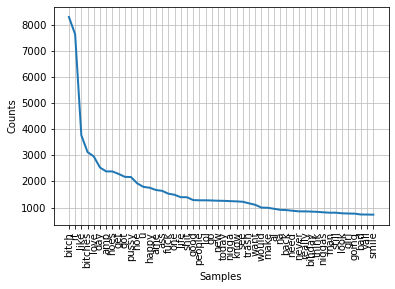

<AxesSubplot:xlabel='Samples', ylabel='Counts'>

In [ ]:
freq_dist.plot(50)

ISPEZIONE DEL TESTO CON nltk.Text

In [ ]:
nltk_text = nltk.Text(tokenized_text)

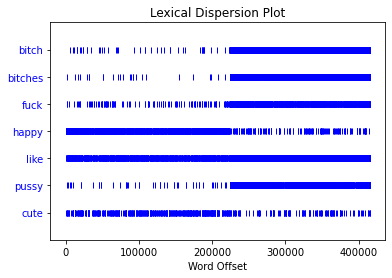

In [ ]:
#how frequently a word appears in various parts of the text
nltk_text.dispersion_plot(['bitch','bitches','fuck', 'happy','like', 'pussy', 'cute'])